### Overview
We will perform supervised land cover classification of Sentinel-2 imagery using a Random Forest classifier. A pre-made cloud-free median composite is loaded directly as a multi-band GeoTIFF. Labeled training points (Ground Control Points) provide one spectral sample per class location. We extract band values at those points, train the classifier, and apply it across the full image to produce a land cover map.

### Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install rioxarray scikit-learn

In [2]:
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import rioxarray as rxr
import xarray as xr
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [3]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

### Load the Composite

We load a pre-made cloud-free Sentinel-2 median composite for 2019 using [`rioxarray`](https://corteva.github.io/rioxarray/stable/). The file is a Cloud Optimized GeoTIFF (COG), so only the metadata is fetched until pixels are actually needed.

In [11]:
composite_url = (
 'https://storage.googleapis.com/spatialthoughts-public-data/python-remote-sensing/bangalore_composite_2019.tif'
)
composite = rxr.open_rasterio(composite_url, mask_and_scale=True)
composite

<xarray.DataArray (band: 3, y: 3426, x: 3510)> Size: 144MB
[36075780 values with dtype=float32]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 27kB 1.454e+06 1.454e+06 ... 1.42e+06 1.42e+06
  * x            (x) float64 28kB 7.67e+05 7.67e+05 ... 8.02e+05 8.02e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area

The composite has integer band indices (1, 2, 3 …). We assign meaningful names so we can select bands by name later.

In [12]:
band_names = ['red', 'green', 'blue']
composite = composite.assign_coords(band=band_names)
composite

<xarray.DataArray (band: 3, y: 3426, x: 3510)> Size: 144MB
[36075780 values with dtype=float32]
Coordinates:
  * band         (band) <U5 60B 'red' 'green' 'blue'
  * y            (y) float64 27kB 1.454e+06 1.454e+06 ... 1.42e+06 1.42e+06
  * x            (x) float64 28kB 7.67e+05 7.67e+05 ... 8.02e+05 8.02e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area

### Load Training Data

The training data is a set of Ground Control Points (GCPs) — point features, each labeled with a land cover class. We load the GeoJSON file with GeoPandas.

In [23]:
training_url = (
    'https://storage.googleapis.com/spatialthoughts-public-data/'
    'python-remote-sensing/bangalore_gcps.geojson'
)
training_gdf = gpd.read_file(training_url)
training_gdf.head()

,id,landcover,geometry
0,00000000000000000000,0,POINT (77.57881 13.27184)
1,00000000000000000001,0,POINT (77.57801 13.27159)
2,00000000000000000002,0,POINT (77.58002 13.27295)
3,00000000000000000003,0,POINT (77.57406 13.27228)
4,00000000000000000004,0,POINT (77.5741 13.27268)


In [19]:
print('Columns:', training_gdf.columns.tolist())
print('CRS:', training_gdf.crs)
print('\nClass distribution:')
print(training_gdf['landcover'].value_counts())

Columns: ['id', 'landcover', 'geometry']
CRS: EPSG:4326

Class distribution:
landcover
0    13
3     8
1     7
2     5
Name: count, dtype: int64


### Visualize Training Data on Composite

We reproject the training points to match the composite CRS, then overlay them on an RGB preview of the composite. This lets us verify that the training points cover the expected land cover types.

In [24]:
image_crs = composite.rio.crs
training_gdf_proj = training_gdf.to_crs(image_crs)

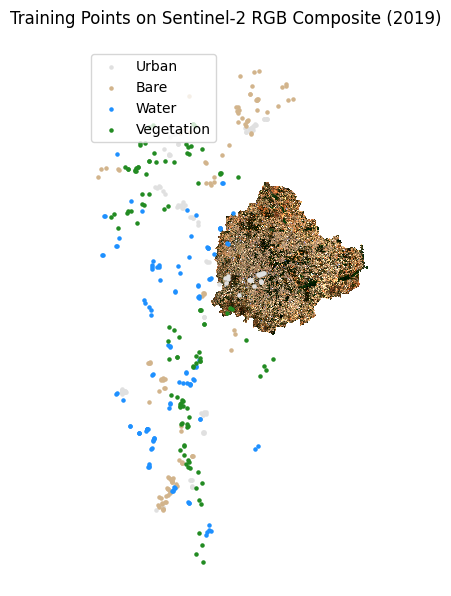

In [25]:
preview = composite.rio.reproject(composite.rio.crs, resolution=100)

class_colors = {
    0: '#E0E0E0', # Urban
    1: '#D2B48C', # Bare
    2: '#1E90FF', # Water
    3: '#228B22', # Vegetation
}

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(7, 7)

preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    robust=True,
)

# Map integer class labels to string names for the legend
class_names = {
    0: 'Urban',
    1: 'Bare',
    2: 'Water',
    3: 'Vegetation'
}

for class_label, group in training_gdf_proj.groupby('landcover'):
    group.plot(
        ax=ax,
        color=class_colors.get(class_label, 'red'),
        markersize=5,
        label=class_names.get(class_label, f'Unknown Class {class_label}')
    )

ax.legend(loc='upper left')
ax.set_title('Training Points on Sentinel-2 RGB Composite (2019)')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()